- Main RQ: How are plant-based food sales patterns related to YouTube narratives across European countries from 2018 to 2020?
- Sub-RQ1: How do plant-based food sales differ across countries, years, and product groups?
- Sub-RQ2: What narratives are most commonly used in YouTube videos about plant-based food across countries and over time?
- Sub-RQ3: To what extent are YouTube narrative variables associated with plant-based food sales value and sales volume?

In [31]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

print(f"current working directory:{os.getcwd()}")
print("\nFiles in current directory:")
print(os.listdir("."))

current working directory:e:\东京大学\Video-Analysis--DataScience-Group\notebooks

Files in current directory:
['0603 Group I.ipynb']


In [32]:
df = pd.read_csv("../data/Clean/plant_based_food_sales_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557 entries, 0 to 3556
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Source File                3557 non-null   object 
 1   Source Sheet               3557 non-null   object 
 2   Country                    3557 non-null   object 
 3   Market                     3557 non-null   object 
 4   Retail Channel             3557 non-null   object 
 5   Product Group              3557 non-null   object 
 6   Product Category           3551 non-null   object 
 7   Product Segment            3468 non-null   object 
 8   Product Subsegment         0 non-null      float64
 9   Product Type               2649 non-null   object 
 10  Product Base / Ingredient  1389 non-null   object 
 11  Private Label              30 non-null     object 
 12  Storage State              114 non-null    object 
 13  Year                       3557 non-null   int64

In [33]:
df= df[['Country', 'Year', 'Value EUR', 'Volume kg/l', 'Product Group']]
df = df.dropna()
df = df[(df['Value EUR'] != 0) & (df['Volume kg/l'] != 0)]
def basics(df):
    print(df.info())
    print(df.head())
basics(df)


<class 'pandas.core.frame.DataFrame'>
Index: 2198 entries, 0 to 3556
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        2198 non-null   object 
 1   Year           2198 non-null   int64  
 2   Value EUR      2198 non-null   float64
 3   Volume kg/l    2198 non-null   float64
 4   Product Group  2198 non-null   object 
dtypes: float64(2), int64(1), object(2)
memory usage: 103.0+ KB
None
   Country  Year   Value EUR  Volume kg/l  \
0  Austria  2018  22667350.5   11365232.9   
1  Austria  2019  26289478.8   13265687.2   
2  Austria  2020  36967737.3   18752705.4   
3  Austria  2018        48.5         17.2   
4  Austria  2019     59668.4      24670.5   

                            Product Group  
0  Plant-based drinks / milk alternatives  
1  Plant-based drinks / milk alternatives  
2  Plant-based drinks / milk alternatives  
3  Plant-based drinks / milk alternatives  
4  Plant-based drinks / milk al

In [38]:
def basics(df):
    print('')
    print('Head')
    print(df.head(2))
    print('')
    print('Tail')
    print(df.tail(2))
    print('')
    print("\nUnique countries in the dataset:")
    print(df.Country.unique())
    print('')
    print("\nUnique years in the dataset:")
    print(df.Year.unique())
    print('')
    print("\nUnique product groups in the dataset:")
    print(df['Product Group'].unique())
basics(df)


Head
   Country  Year   Value EUR  Volume kg/l  \
0  Austria  2018  22667350.5   11365232.9   
1  Austria  2019  26289478.8   13265687.2   

                            Product Group  
0  Plant-based drinks / milk alternatives  
1  Plant-based drinks / milk alternatives  

Tail
             Country  Year     Value EUR  Volume kg/l      Product Group
3553  United Kingdom  2020  409790.55039      35233.1  Meat alternatives
3556  United Kingdom  2020       2.19756          0.4  Meat alternatives


Unique countries in the dataset:
['Austria' 'Belgium' 'Denmark' 'France' 'Italy' 'Netherlands' 'Romania'
 'Spain' 'United Kingdom']


Unique years in the dataset:
[2018 2019 2020]


Unique product groups in the dataset:
['Plant-based drinks / milk alternatives' 'Plant-based alternatives'
 'Meat alternatives' 'Plant-based yogurt' 'Cheese alternatives'
 'Plant-based ice cream']


In [39]:
country_descriptive = df.groupby('Country')[['Value EUR', 'Volume kg/l']].describe()
country_descriptive

Value EUR                                          \
                   count          mean           std         min   
Country                                                            
Austria            284.0  1.808200e+06  4.077678e+06    1.800000   
Belgium            114.0  6.839698e+06  1.160210e+07   13.500000   
Denmark            189.0  1.302089e+06  3.697090e+06    0.004024   
France             278.0  8.213226e+06  2.326887e+07    1.600000   
Italy              434.0  1.065034e+07  3.038677e+07    1.300000   
Netherlands        270.0  7.314678e+06  1.800906e+07    2.700000   
Romania             48.0  1.427317e+06  2.630310e+06    3.341174   
Spain              124.0  2.489738e+07  5.689469e+07  237.400000   
United Kingdom     457.0  8.761826e+06  2.990147e+07    2.197560   

                                                                         \
                          25%           50%           75%           max   
Country                                                                   
Austria          37291.525000  3.730940e+05  1.593272e+06  3.696774e+07   
Belgium         117249.900000  1.397411e+06  4.692208e+06  4.840670e+07   
Denmark            136.140495  1.517126e+03  2.090265e+05  2.568121e+07   
France           44521.075000  5.817103e+05  4.532617e+06  1.873759e+08   
Italy            34817.400000  6.251733e+05  5.280833e+06  2.311767e+08   
Netherlands      99891.750000  1.019150e+06  7.319974e+06  1.735190e+08   
Romania         122032.921312  4.757183e+05  1.237929e+06  1.370074e+07   
Spain           333901.050000  2.024559e+06  2.097019e+07  3.184199e+08   
United Kingdom  100360.038006  1.011396e+06  4.701870e+06  2.636784e+08   

               Volume kg/l                                          \
                     count          mean           std         min   
Country                                                              
Austria              284.0  5.459139e+05  1.690464e+06    0.300000   
Belgium              114.0  2.300202e+06  4.256722e+06    2.500000   
Denmark              189.0  5.765487e+05  1.742014e+06    0.000142   
France               278.0  2.728780e+06  1.022208e+07    0.200000   
Italy                434.0  2.815505e+06  1.129324e+07    0.200000   
Netherlands          270.0  1.636748e+06  4.438407e+06    0.800000   
Romania               48.0  5.378859e+05  1.227752e+06    2.300000   
Spain                124.0  1.663794e+07  4.266212e+07  110.000000   
United Kingdom       457.0  2.229096e+06  1.308289e+07    0.400000   

                                                                         
                          25%            50%          75%           max  
Country                                                                  
Austria           5152.025000   44301.800000   303402.725  1.875271e+07  
Belgium          50226.625000  429901.250000  2342629.525  2.310212e+07  
Denmark             10.617436     190.669056    45871.000  1.232558e+07  
France            9437.125000  151792.100000  1137229.875  9.627524e+07  
Italy             3369.050000   58640.350000   792707.625  1.196656e+08  
Netherlands      19640.800000  161027.300000  1259307.025  3.951199e+07  
Romania          30099.025000  119758.400000   348039.775  6.433074e+06  
Spain           152760.000000  992275.000000  9686870.000  2.455686e+08  
United Kingdom    9257.600000   98196.900000   496222.300  1.455053e+08

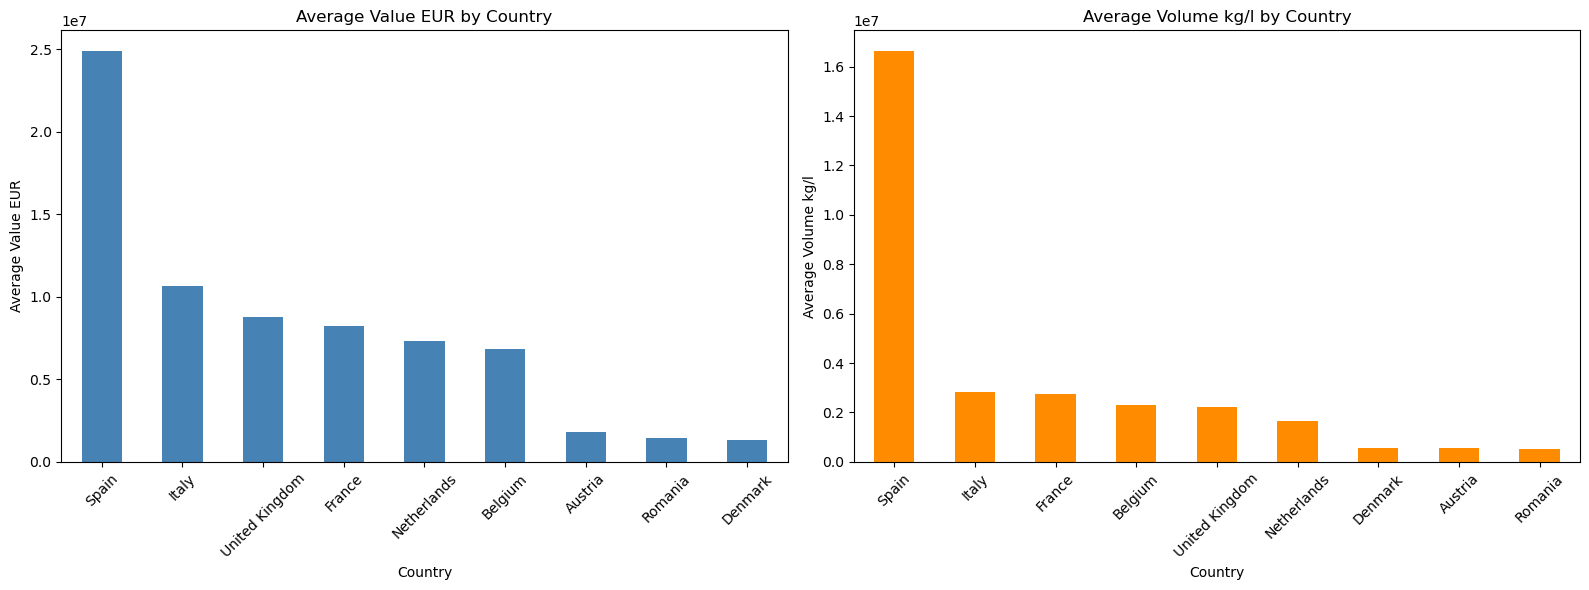

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

country_mean['Value EUR'].sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[0],
    color='steelblue'
)

axes[0].set_title('Average Value EUR by Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Average Value EUR')
axes[0].tick_params(axis='x', rotation=45)

country_mean['Volume kg/l'].sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[1],
    color='darkorange'
)

axes[1].set_title('Average Volume kg/l by Country')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Average Volume kg/l')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

This above figure compares the average market value and average sales volume of plant-based food products across countries. Spain shows the highest average value in EUR and the highest average volume kg/l, indicating that it has the largest market scale among the countries included in the dataset. Italy, France, the United Kingdom, Belgium, and the Netherlands form a middle group, with relatively strong average value and volume compared with Austria, Romania, and Denmark. Overall, the two charts show a similar pattern: countries with higher average value also tend to have higher average volume, suggesting that larger monetary sales are generally associated with larger physical sales volumes. Spain is the clear outlier in both measures.

In [40]:
year_descriptive = df.groupby('Year')[['Value EUR', 'Volume kg/l']].describe()
year_descriptive

Value EUR                                                                 \
         count          mean           std       min           25%        50%   
Year                                                                            
2018     690.0  7.343358e+06  2.403653e+07  0.004024  31049.665831  582894.45   
2019     745.0  7.629588e+06  2.496435e+07  0.004024  30035.800000  592967.00   
2020     763.0  8.949955e+06  2.950429e+07  0.025930  43707.382531  778288.70   

                                Volume kg/l                              \
               75%          max       count          mean           std   
Year                                                                      
2018  3.662025e+06  275679389.8       690.0  2.613446e+06  1.284878e+07   
2019  3.920635e+06  282010043.8       745.0  2.632281e+06  1.315350e+07   
2020  4.816004e+06  318419886.6       763.0  3.003899e+06  1.533722e+07   

                                                             
           min       25%       50%         75%          max  
Year                                                         
2018  0.000200  4715.075   86340.0  776484.475  213185810.0  
2019  0.000142  4111.900   87058.5  761895.500  217391040.0  
2020  0.001980  5910.500  103854.7  936815.800  245568610.0

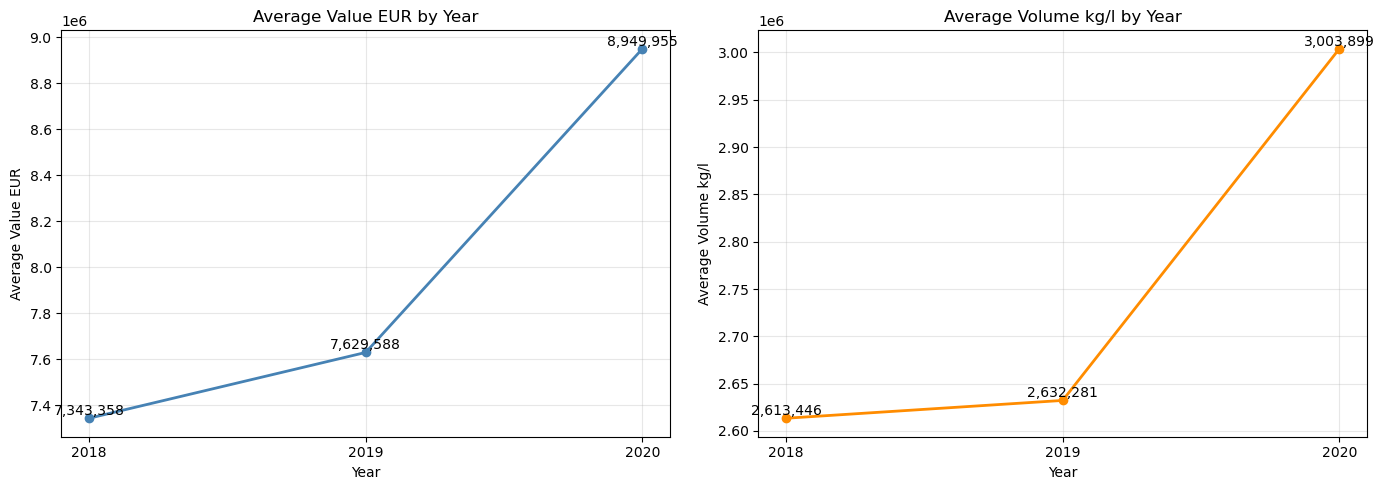

In [51]:
import matplotlib.pyplot as plt

year_mean = df.groupby('Year')[['Value EUR', 'Volume kg/l']].mean()

years = [2018, 2019, 2020]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Value EUR trend
axes[0].plot(
    year_mean.index,
    year_mean['Value EUR'],
    marker='o',
    linewidth=2,
    color='steelblue'
)

axes[0].set_title('Average Value EUR by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Value EUR')
axes[0].set_xticks(years)
axes[0].set_xticklabels(['2018', '2019', '2020'])
axes[0].grid(True, alpha=0.3)

for x, y in zip(year_mean.index, year_mean['Value EUR']):
    axes[0].text(x, y, f'{y:,.0f}', ha='center', va='bottom')

# Volume kg/l trend
axes[1].plot(
    year_mean.index,
    year_mean['Volume kg/l'],
    marker='o',
    linewidth=2,
    color='darkorange'
)

axes[1].set_title('Average Volume kg/l by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Volume kg/l')
axes[1].set_xticks(years)
axes[1].set_xticklabels(['2018', '2019', '2020'])
axes[1].grid(True, alpha=0.3)

for x, y in zip(year_mean.index, year_mean['Volume kg/l']):
    axes[1].text(x, y, f'{y:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

This figure shows the yearly trend in average market value and average sales volume of plant-based food products from 2018 to 2020. Both indicators increased over the period. The average value rose from approximately EUR 7.34 million in 2018 to EUR 7.63 million in 2019, then increased more sharply to around EUR 8.95 million in 2020. A similar pattern can be seen in average volume, which remained relatively stable between 2018 and 2019, increasing only slightly from about 2.61 million kg/l to 2.63 million kg/l, before rising more noticeably to about 3.00 million kg/l in 2020. Overall, the results suggest that the plant-based food market expanded over time, with the strongest growth occurring between 2019 and 2020.

In [41]:
Product_Group_descriptive = df.groupby('Product Group')[['Value EUR', 'Volume kg/l']].describe()
Product_Group_descriptive

Value EUR                              \
                                           count          mean           std   
Product Group                                                                  
Cheese alternatives                        434.0  5.951290e+06  2.268962e+07   
Meat alternatives                          763.0  7.370895e+06  2.223610e+07   
Plant-based alternatives                   122.0  1.140349e+06  3.065609e+06   
Plant-based drinks / milk alternatives     675.0  1.121092e+07  3.584937e+07   
Plant-based ice cream                       46.0  4.659149e+06  8.968439e+06   
Plant-based yogurt                         158.0  9.190567e+06  1.595164e+07   

                                                                               \
                                             min            25%           50%   
Product Group                                                                   
Cheese alternatives                     0.004024    4399.825000  1.725374e+05   
Meat alternatives                       2.197560  108639.015672  1.085403e+06   
Plant-based alternatives                1.800000   19775.525000  2.510889e+05   
Plant-based drinks / milk alternatives  2.008532   52113.050000  7.104117e+05   
Plant-based ice cream                   0.006718     573.315150  2.732532e+03   
Plant-based yogurt                      1.600000   73633.450000  1.427259e+06   

                                                                    \
                                                 75%           max   
Product Group                                                        
Cheese alternatives                     1.860597e+06  1.862081e+08   
Meat alternatives                       4.677351e+06  2.636784e+08   
Plant-based alternatives                8.286052e+05  2.487451e+07   
Plant-based drinks / milk alternatives  4.945481e+06  3.184199e+08   
Plant-based ice cream                   4.120230e+06  3.278527e+07   
Plant-based yogurt                      1.132420e+07  8.708930e+07   

                                       Volume kg/l                \
                                             count          mean   
Product Group                                                      
Cheese alternatives                          434.0  6.189760e+05   
Meat alternatives                            763.0  7.614865e+05   
Plant-based alternatives                     122.0  8.590506e+04   
Plant-based drinks / milk alternatives       675.0  7.106742e+06   
Plant-based ice cream                         46.0  5.245179e+05   
Plant-based yogurt                           158.0  2.373373e+06   

                                                                              \
                                                 std       min           25%   
Product Group                                                                  
Cheese alternatives                     2.340277e+06  0.000200    308.825000   
Meat alternatives                       2.491777e+06  0.393120  10635.250000   
Plant-based alternatives                2.470145e+05  0.300000   1735.500000   
Plant-based drinks / milk alternatives  2.414808e+07  0.330000  16148.000000   
Plant-based ice cream                   9.686499e+05  0.000142     42.619186   
Plant-based yogurt                      4.139750e+06  0.200000  22618.900000   

                                                                    \
                                                  50%          75%   
Product Group                                                        
Cheese alternatives                      14795.750000   153973.900   
Meat alternatives                       116378.300000   500693.950   
Plant-based alternatives                 19089.700000    53038.975   
Plant-based drinks / milk alternatives  318140.000000  2569518.500   
Plant-based ice cream                      229.842487   544641.800   
Plant-based yogurt                      468299.541000  2367222.

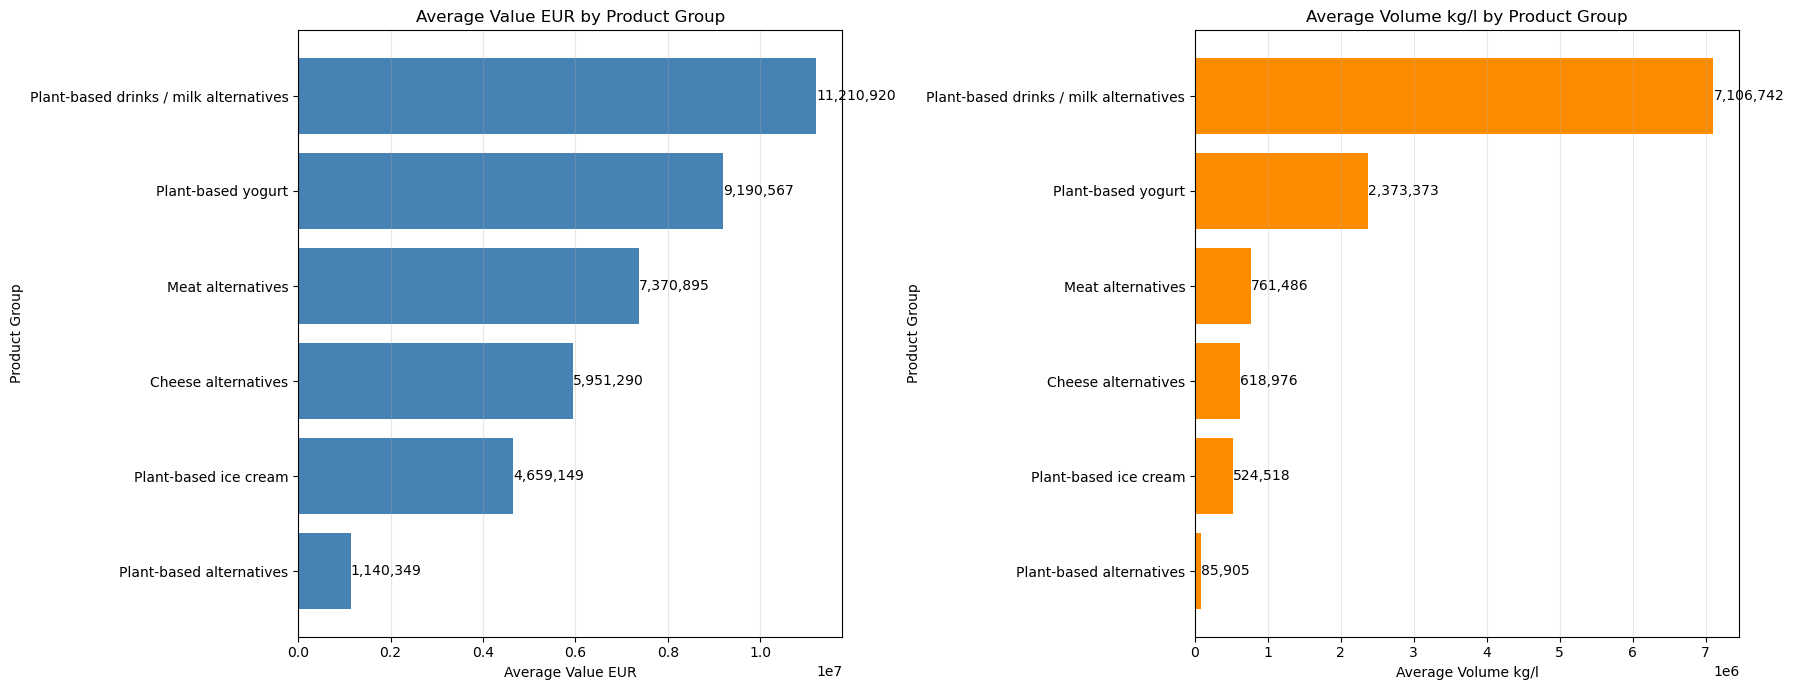

In [52]:
import matplotlib.pyplot as plt

product_mean = df.groupby('Product Group')[['Value EUR', 'Volume kg/l']].mean()

value_sorted = product_mean.sort_values('Value EUR', ascending=True)
volume_sorted = product_mean.sort_values('Volume kg/l', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

bars1 = axes[0].barh(
    value_sorted.index,
    value_sorted['Value EUR'],
    color='steelblue'
)

axes[0].set_title('Average Value EUR by Product Group')
axes[0].set_xlabel('Average Value EUR')
axes[0].set_ylabel('Product Group')
axes[0].grid(axis='x', alpha=0.3)

for bar in bars1:
    width = bar.get_width()
    axes[0].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}',
        va='center',
        ha='left'
    )

bars2 = axes[1].barh(
    volume_sorted.index,
    volume_sorted['Volume kg/l'],
    color='darkorange'
)

axes[1].set_title('Average Volume kg/l by Product Group')
axes[1].set_xlabel('Average Volume kg/l')
axes[1].set_ylabel('Product Group')
axes[1].grid(axis='x', alpha=0.3)

for bar in bars2:
    width = bar.get_width()
    axes[1].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}',
        va='center',
        ha='left'
    )

plt.tight_layout()
plt.show()

This figure compares the average market value and average sales volume across different plant-based product groups. Plant-based drinks and milk alternatives are the leading category in both measures, with the highest average value and by far the highest average volume. Plant-based yogurt is the second largest category, showing relatively strong performance in both value and volume. Meat alternatives also have a high average value, but their average volume is much lower than drinks and yogurt, suggesting a higher value per unit or a smaller but more valuable market segment. Cheese alternatives and plant-based ice cream are in the middle to lower range, while the general plant-based alternatives category records the lowest average value and volume. Overall, the results show that plant-based drinks and milk alternatives dominate the dataset, especially in terms of physical sales volume.

                            OLS Regression Results                            
Dep. Variable:              Value EUR   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     4705.
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:31:00   Log-Likelihood:                -39418.
No. Observations:                2198   AIC:                         7.884e+04
Df Residuals:                    2196   BIC:                         7.885e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         3.67e+06   3.23e+05     11.349      

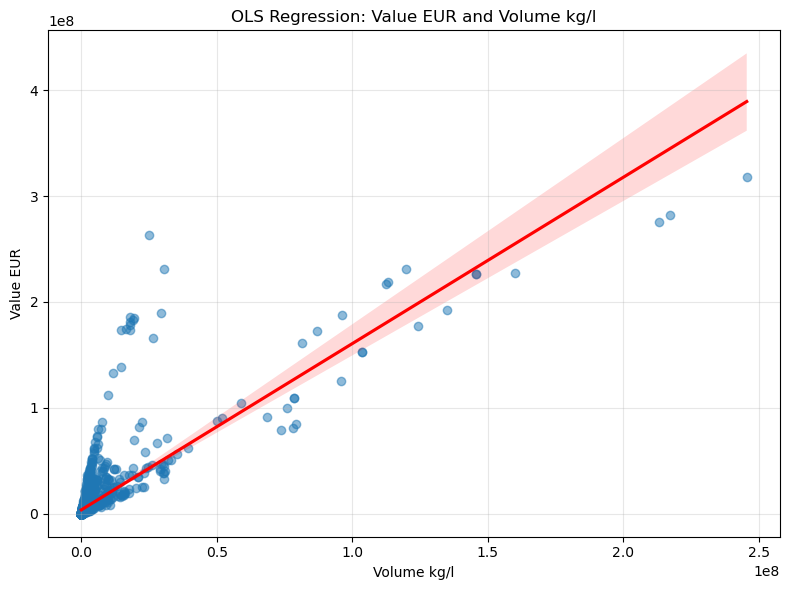

In [53]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
reg_df = df[['Value EUR', 'Volume kg/l']].dropna()

# Remove zero or negative values if needed
reg_df = reg_df[
    (reg_df['Value EUR'] > 0) &
    (reg_df['Volume kg/l'] > 0)
]

# Define X and y
X = reg_df[['Volume kg/l']]
y = reg_df['Value EUR']

# Add constant / intercept
X = sm.add_constant(X)

# Fit OLS regression model
model = sm.OLS(y, X).fit()

# Show regression result
print(model.summary())

plt.figure(figsize=(8, 6))

sns.regplot(
    data=reg_df,
    x='Volume kg/l',
    y='Value EUR',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title('OLS Regression: Value EUR and Volume kg/l')
plt.xlabel('Volume kg/l')
plt.ylabel('Value EUR')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The OLS regression results show a positive and statistically significant relationship between sales volume and value in EUR. The coefficient of Volume kg/l is 1.5706, meaning that, on average, a one-unit increase in sales volume is associated with an increase of about 1.57 EUR in value. The p-value is 0.000, which is below the 0.05 significance level, indicating that this positive relationship is statistically significant.
The R-squared value is 0.682, meaning that approximately 68.2% of the variation in Value EUR can be explained by Volume kg/l. This suggests that sales volume is an important predictor of market value.
Although this positive relationship is intuitive, it is still necessary to test it statistically. In theory, higher sales volume should be associated with higher sales value. However, the relationship may not always be perfectly consistent because price changes can also affect value. For example, if prices increase or decrease significantly, the change in value may not move exactly in line with the change in sales volume. Therefore, testing the relationship helps us understand whether sales value mainly follows sales volume, or whether price variation may also play an important role.

API

> **Note:** The following code was used to extract video information through the YouTube API. Since it requires a personal API key and repeated execution may trigger API quota limits, it is included as a Markdown section rather than an executable code cell. The CSV files generated from this process are then combined in the next step into a complete CSV file and stored in the `data/Raw` folder.


import requests
import pandas as pd
import time
from pathlib import Path
from datetime import datetime

API_KEY = "PASTE YOUR OWN API_KEY"

PAGES_PER_QUERY = 1
REQUEST_SLEEP_SECONDS = 2

PUBLISHED_AFTER = "2018-01-01T00:00:00Z"
PUBLISHED_BEFORE = "2021-01-01T00:00:00Z"

OUTPUT_DIR =Path("../data/Raw")

COUNTRIES = [
    {"country": "Austria", "region_code": "AT", "language": "de", "local_name": "Austria Osterreich"},
    {"country": "Belgium", "region_code": "BE", "language": "nl", "local_name": "Belgium Belgie Belgique"},
    {"country": "Denmark", "region_code": "DK", "language": "da", "local_name": "Denmark Danmark"},
    {"country": "France", "region_code": "FR", "language": "fr", "local_name": "France"},
    {"country": "Italy", "region_code": "IT", "language": "it", "local_name": "Italy Italia"},
    {"country": "Netherlands", "region_code": "NL", "language": "nl", "local_name": "Netherlands Nederland"},
    {"country": "Romania", "region_code": "RO", "language": "ro", "local_name": "Romania"},
    {"country": "Spain", "region_code": "ES", "language": "es", "local_name": "Spain Espana"},
    {"country": "United Kingdom", "region_code": "GB", "language": "en", "local_name": "United Kingdom UK Britain"},
]

# Change this later if you want another country
SELECTED_COUNTRY_NAME = "United Kingdom"

QUERY_TEMPLATES = [
    "plant based food {country} consumer behaviour",
    "plant based meat {country} consumers",
    "vegan food {country} consumer trends",
    "plant based diet {country} supermarket",
    "meat alternatives {country} shoppers",
    "vegan products {country} consumers",
    "plant based food {local_name} sustainability",
    "vegan {local_name} supermarket",
]


def get_country_config(country_name):
    for country in COUNTRIES:
        if country["country"] == country_name:
            return country
    raise ValueError(f"Country not found: {country_name}")


def youtube_get(endpoint, params, max_retries=5):
    url = f"https://www.googleapis.com/youtube/v3/{endpoint}"
    params = dict(params)
    params["key"] = API_KEY

    for attempt in range(max_retries):
        response = requests.get(url, params=params, timeout=30)

        if response.status_code == 429:
            wait_time = 30 * (attempt + 1)
            print(f"429 Too Many Requests. Waiting {wait_time} seconds...")
            time.sleep(wait_time)
            continue

        if response.status_code == 403:
            print("403 error. You may have reached your YouTube API quota limit.")
            print(response.text)
            response.raise_for_status()

        response.raise_for_status()
        time.sleep(REQUEST_SLEEP_SECONDS)
        return response.json()

    raise Exception("Too many requests. Please wait and run again later.")


def search_videos(country_config):
    video_rows = []
    seen = set()

    queries = [
        template.format(
            country=country_config["country"],
            local_name=country_config["local_name"]
        )
        for template in QUERY_TEMPLATES
    ]

    for query in queries:
        print("Query:", query)

        page_token = None

        for _ in range(PAGES_PER_QUERY):
            params = {
                "part": "snippet",
                "type": "video",
                "q": query,
                "maxResults": 50,
                "regionCode": country_config["region_code"],
                "relevanceLanguage": country_config["language"],
                "publishedAfter": PUBLISHED_AFTER,
                "publishedBefore": PUBLISHED_BEFORE,
                "safeSearch": "none",
                "order": "relevance",
            }

            if page_token:
                params["pageToken"] = page_token

            data = youtube_get("search", params)

            for item in data.get("items", []):
                video_id = item.get("id", {}).get("videoId")

                if video_id and video_id not in seen:
                    seen.add(video_id)
                    video_rows.append({
                        "country": country_config["country"],
                        "search_region_code": country_config["region_code"],
                        "search_language": country_config["language"],
                        "video_id": video_id,
                    })

            page_token = data.get("nextPageToken")

            if not page_token:
                break

    return video_rows


def fetch_video_details(video_ids):
    all_items = []

    for start in range(0, len(video_ids), 50):
        chunk = video_ids[start:start + 50]

        if len(chunk) == 0:
            continue

        params = {
            "part": "snippet,statistics,contentDetails",
            "id": ",".join(chunk),
            "maxResults": 50,
        }

        data = youtube_get("videos", params)
        all_items.extend(data.get("items", []))

    return all_items


def fetch_channel_details(channel_ids):
    channels = {}
    unique_channel_ids = list(set(channel_ids))

    for start in range(0, len(unique_channel_ids), 50):
        chunk = unique_channel_ids[start:start + 50]

        if len(chunk) == 0:
            continue

        params = {
            "part": "snippet,statistics,brandingSettings",
            "id": ",".join(chunk),
            "maxResults": 50,
        }

        data = youtube_get("channels", params)

        for item in data.get("items", []):
            channels[item["id"]] = item

    return channels


def clean_text(text):
    if text is None:
        return ""
    return " ".join(str(text).replace("\n", " ").replace("\r", " ").split())


def build_final_rows(search_rows, video_details, channel_details):
    details_by_id = {
        item["id"]: item
        for item in video_details
    }

    final_rows = []

    for row in search_rows:
        video_id = row["video_id"]
        item = details_by_id.get(video_id)

        if item is None:
            continue

        snippet = item.get("snippet", {})
        statistics = item.get("statistics", {})

        channel_id = snippet.get("channelId", "")
        channel = channel_details.get(channel_id, {})

        channel_country = (
            channel
            .get("brandingSettings", {})
            .get("channel", {})
            .get("country", "")
        )

        published_at = snippet.get("publishedAt", "")

        final_rows.append({
            "country": row["country"],
            "search_region_code": row["search_region_code"],
            "search_language": row["search_language"],
            "channel_country": channel_country,
            "default_language": snippet.get("defaultLanguage", ""),
            "default_audio_language": snippet.get("defaultAudioLanguage", ""),
            "video_id": video_id,
            "url": f"https://www.youtube.com/watch?v={video_id}",
            "title": clean_text(snippet.get("title", "")),
            "upload_date": published_at[:10],
            "published_at": published_at,
            "channel": snippet.get("channelTitle", ""),
            "channel_id": channel_id,
            "view_count": statistics.get("viewCount", ""),
            "like_count": statistics.get("likeCount", ""),
            "comment_count": statistics.get("commentCount", ""),
            "description": clean_text(snippet.get("description", "")),
        })

    return final_rows


country_config = get_country_config(SELECTED_COUNTRY_NAME)

print("==============================")
print(f"Searching {country_config['country']}")
print("==============================")

search_rows = search_videos(country_config)
search_df = pd.DataFrame(search_rows)

print("\nTotal rows:", len(search_df))

if len(search_df) > 0:
    print("Unique videos:", search_df["video_id"].nunique())

    unique_video_ids = search_df["video_id"].drop_duplicates().tolist()

    print("\nFetching video details...")
    video_details = fetch_video_details(unique_video_ids)

    channel_ids = [
        item.get("snippet", {}).get("channelId")
        for item in video_details
        if item.get("snippet", {}).get("channelId")
    ]

    print("Fetching channel details...")
    channel_details = fetch_channel_details(channel_ids)

    final_rows = build_final_rows(
        search_rows,
        video_details,
        channel_details
    )

    df_youtube = pd.DataFrame(final_rows)

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    country_file_name = SELECTED_COUNTRY_NAME.lower().replace(" ", "_")

    csv_path = OUTPUT_DIR / f"youtube_plant_based_{country_file_name}_{stamp}.csv"
    json_path = OUTPUT_DIR / f"youtube_plant_based_{country_file_name}_{stamp}.json"

    df_youtube.to_csv(csv_path, index=False, encoding="utf-8-sig")
    df_youtube.to_json(json_path, orient="records", force_ascii=False, indent=2)

    print("\nDone.")
    print("Rows saved:", len(df_youtube))
    print("CSV saved to:", csv_path)
    print("JSON saved to:", json_path)

    display(df_youtube.head())

else:
    print("No videos found. Try changing queries or checking your API key.")

In [65]:
import pandas as pd
from pathlib import Path

# Folder where your country-level YouTube CSV files are saved
folder = Path("../data/Raw")

# Find all country-level CSV files
csv_files = list(folder.glob("youtube_plant_based_*.csv"))

# Exclude already-combined files if they exist
csv_files = [
    file for file in csv_files
    if "all_countries" not in file.name
]

print("Number of CSV files found:", len(csv_files))

for file in csv_files:
    print(file.name)

if len(csv_files) == 0:
    raise ValueError("No CSV files found. Please check your folder path.")

df_list = []

for file in csv_files:
    temp_df = pd.read_csv(file)

    # Add source file name for tracking
    temp_df["source_file"] = file.name

    df_list.append(temp_df)

# Combine all CSV files
df_all_youtube = pd.concat(df_list, ignore_index=True)

# Remove duplicated rows if the same video appears more than once for the same country
if {"country", "video_id"}.issubset(df_all_youtube.columns):
    df_all_youtube = df_all_youtube.drop_duplicates(
        subset=["country", "video_id"]
    )
else:
    print("Warning: country or video_id column not found. Skipping duplicate removal by country and video_id.")

# Save combined CSV
output_path = folder / "youtube_plant_based_all_countries.csv"

df_all_youtube.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nDone.")
print("Total rows:", len(df_all_youtube))
print("Saved to:", output_path)

display(df_all_youtube.head())

Number of CSV files found: 9
youtube_plant_based_austria_20260602_214414.csv
youtube_plant_based_belgium_20260602_214556.csv
youtube_plant_based_denmark_20260602_214710.csv
youtube_plant_based_france_20260602_214839.csv
youtube_plant_based_italy_20260602_215007.csv
youtube_plant_based_netherlands_20260602_215107.csv
youtube_plant_based_romania_20260602_215157.csv
youtube_plant_based_spain_20260602_215249.csv
youtube_plant_based_united_kingdom_20260602_214155.csv

Done.
Total rows: 2843
Saved to: ..\data\Raw\youtube_plant_based_all_countries.csv


,country,search_region_code,search_language,channel_country,default_language,default_audio_language,video_id,url,title,upload_date,published_at,channel,channel_id,view_count,like_count,comment_count,description,source_file
0,Austria,AT,de,US,en,en,MZsoQqMnPZI,https://www.youtube.com/watch?v=MZsoQqMnPZI,Janitorial Restroom Cleaning Step-By-Step Trai...,2018-09-13,2018-09-13T19:58:15Z,Relay Resources,UCA9jhkyeyeU3NS57ATgmAXw,2183087,25217.0,121.0,A building interior sets the stage for how peo...,youtube_plant_based_austria_20260602_214414.csv
1,Austria,AT,de,US,en,en,4a4gshhnb7Q,https://www.youtube.com/watch?v=4a4gshhnb7Q,Why Mcdonalds Doesnt Have a Vegan Burger in th...,2019-06-21,2019-06-21T20:48:57Z,Ripe,UC2OuoOnXZ-EosStugaJoWsg,431,19.0,4.0,"While fast food chains Burger King, White Cast...",youtube_plant_based_austria_20260602_214414.csv
2,Austria,AT,de,US,en,NaN,GGc-Z1AyIFY,https://www.youtube.com/watch?v=GGc-Z1AyIFY,H.O.P.E - The Documentary - What You Eat Matte...,2020-04-02,2020-04-02T15:14:16Z,Indie Film Trailers,UCyR9ic1YgBCOHK5HSYdN1IA,115,2.0,0.0,Half of the population in Western society suff...,youtube_plant_based_austria_20260602_214414.csv
3,Austria,AT,de,NaN,en,NaN,I7oLRSEt7Ag,https://www.youtube.com/watch?v=I7oLRSEt7Ag,H O P E What You Eat Matters - Trailer,2020-10-07,2020-10-07T12:27:42Z,Films For Change,UC3oDRtIlvdaVfHoDEtbl6MQ,15,0.0,0.0,Watch the film: https://filmsforchange.stream/...,youtube_plant_based_austria_20260602_214414.csv
4,Austria,AT,de,DE,de,zxx,msbyMI-aZ0o,https://www.youtube.com/watch?v=msbyMI-aZ0o,Vegan businesses in China - and the transforma...,2020-03-04,2020-03-04T13:34:56Z,Veganes Sommerfest Berlin,UC3I0FcY9almVM0oLpiZM9uw,93,4.0,0.0,Shara Ng - Chairwoman of the Hong Kong Plant B...,youtube_plant_based_austria_20260602_214414.csv


In [66]:
import pandas as pd
import re
from pathlib import Path

# Load combined YouTube data
youtube_path = Path("../data/Raw/youtube_plant_based_all_countries.csv")

df_youtube = pd.read_csv(youtube_path)

print(df_youtube.shape)
display(df_youtube.head())

(2843, 18)


,country,search_region_code,search_language,channel_country,default_language,default_audio_language,video_id,url,title,upload_date,published_at,channel,channel_id,view_count,like_count,comment_count,description,source_file
0,Austria,AT,de,US,en,en,MZsoQqMnPZI,https://www.youtube.com/watch?v=MZsoQqMnPZI,Janitorial Restroom Cleaning Step-By-Step Trai...,2018-09-13,2018-09-13T19:58:15Z,Relay Resources,UCA9jhkyeyeU3NS57ATgmAXw,2183087,25217.0,121.0,A building interior sets the stage for how peo...,youtube_plant_based_austria_20260602_214414.csv
1,Austria,AT,de,US,en,en,4a4gshhnb7Q,https://www.youtube.com/watch?v=4a4gshhnb7Q,Why Mcdonalds Doesnt Have a Vegan Burger in th...,2019-06-21,2019-06-21T20:48:57Z,Ripe,UC2OuoOnXZ-EosStugaJoWsg,431,19.0,4.0,"While fast food chains Burger King, White Cast...",youtube_plant_based_austria_20260602_214414.csv
2,Austria,AT,de,US,en,NaN,GGc-Z1AyIFY,https://www.youtube.com/watch?v=GGc-Z1AyIFY,H.O.P.E - The Documentary - What You Eat Matte...,2020-04-02,2020-04-02T15:14:16Z,Indie Film Trailers,UCyR9ic1YgBCOHK5HSYdN1IA,115,2.0,0.0,Half of the population in Western society suff...,youtube_plant_based_austria_20260602_214414.csv
3,Austria,AT,de,NaN,en,NaN,I7oLRSEt7Ag,https://www.youtube.com/watch?v=I7oLRSEt7Ag,H O P E What You Eat Matters - Trailer,2020-10-07,2020-10-07T12:27:42Z,Films For Change,UC3oDRtIlvdaVfHoDEtbl6MQ,15,0.0,0.0,Watch the film: https://filmsforchange.stream/...,youtube_plant_based_austria_20260602_214414.csv
4,Austria,AT,de,DE,de,zxx,msbyMI-aZ0o,https://www.youtube.com/watch?v=msbyMI-aZ0o,Vegan businesses in China - and the transforma...,2020-03-04,2020-03-04T13:34:56Z,Veganes Sommerfest Berlin,UC3I0FcY9almVM0oLpiZM9uw,93,4.0,0.0,Shara Ng - Chairwoman of the Hong Kong Plant B...,youtube_plant_based_austria_20260602_214414.csv


In [67]:
# Make sure date/year exists
df_youtube["upload_date"] = pd.to_datetime(df_youtube["upload_date"], errors="coerce")
df_youtube["Year"] = df_youtube["upload_date"].dt.year

# Combine text columns for narrative analysis
text_cols = ["title", "description", "summary"]

for col in text_cols:
    if col not in df_youtube.columns:
        df_youtube[col] = ""

df_youtube["text_for_analysis"] = (
    df_youtube[text_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)

In [68]:
narrative_keywords = {
    "health": [
        "health", "healthy", "nutrition", "nutritious", "protein", "diet",
        "wellbeing", "wellness", "fitness", "low fat", "cholesterol",
        "sugar free", "natural", "organic",
        "santé", "salud", "gesund", "gesundheit", "salute", "gezond",
    ],

    "sustainability": [
        "sustainable", "sustainability", "eco", "green", "ethical",
        "responsible", "future", "planet friendly",
        "durable", "durabilité", "sostenible", "nachhaltig",
        "sostenibilità", "duurzaam",
    ],

    "environment": [
        "environment", "environmental", "climate", "carbon", "co2",
        "emissions", "greenhouse gas", "planet", "earth", "pollution",
        "biodiversity", "water use", "land use",
        "climat", "clima", "klima", "ambiente", "milieu",
    ],

    "hedonism": [
        "taste", "tasty", "delicious", "flavour", "flavor", "yummy",
        "enjoy", "pleasure", "craving", "juicy", "crispy", "creamy",
        "comfort food", "indulgent",
        "goût", "délicieux", "sabor", "rico", "sabroso",
        "geschmack", "lecker", "gusto", "smaak", "lekker",
    ],

    "animal_welfare": [
        "animal welfare", "animal", "animals", "cruelty", "cruelty free",
        "ethical", "slaughter", "factory farming", "livestock",
        "cows", "pigs", "chickens",
        "bien-être animal", "bienestar animal", "tierschutz",
        "benessere animale", "dierenwelzijn",
    ],
}

In [71]:
# Make sure upload_date and Year are available
df_youtube["upload_date"] = pd.to_datetime(df_youtube["upload_date"], errors="coerce")
df_youtube["Year"] = df_youtube["upload_date"].dt.year

# Make sure text columns exist
text_cols = ["title", "description"]

for col in text_cols:
    if col not in df_youtube.columns:
        df_youtube[col] = ""

# Combine title and description for narrative analysis
df_youtube["text_for_analysis"] = (
    df_youtube[text_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)

In [72]:
import re

def count_keywords(text, keywords):
    if pd.isna(text):
        return 0
    
    text = str(text).lower()
    count = 0
    
    for keyword in keywords:
        pattern = r"\b" + re.escape(keyword.lower()) + r"\b"
        count += len(re.findall(pattern, text))
    
    return count


for narrative, keywords in narrative_keywords.items():
    df_youtube[f"{narrative}_count"] = df_youtube["text_for_analysis"].apply(
        lambda x: count_keywords(x, keywords)
    )

df_youtube.head()

,country,search_region_code,search_language,channel_country,default_language,default_audio_language,video_id,url,title,upload_date,...,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned
0,Austria,AT,de,US,en,en,MZsoQqMnPZI,https://www.youtube.com/watch?v=MZsoQqMnPZI,Janitorial Restroom Cleaning Step-By-Step Trai...,2018-09-13,...,0,0,0,0,0,0,0,0,0,0
1,Austria,AT,de,US,en,en,4a4gshhnb7Q,https://www.youtube.com/watch?v=4a4gshhnb7Q,Why Mcdonalds Doesnt Have a Vegan Burger in th...,2019-06-21,...,0,0,0,0,0,0,0,0,0,0
2,Austria,AT,de,US,en,NaN,GGc-Z1AyIFY,https://www.youtube.com/watch?v=GGc-Z1AyIFY,H.O.P.E - The Documentary - What You Eat Matte...,2020-04-02,...,5,2,3,0,3,1,1,1,0,1
3,Austria,AT,de,NaN,en,NaN,I7oLRSEt7Ag,https://www.youtube.com/watch?v=I7oLRSEt7Ag,H O P E What You Eat Matters - Trailer,2020-10-07,...,5,2,3,0,3,1,1,1,0,1
4,Austria,AT,de,DE,de,zxx,msbyMI-aZ0o,https://www.youtube.com/watch?v=msbyMI-aZ0o,Vegan businesses in China - and the transforma...,2020-03-04,...,0,0,0,0,1,0,0,0,0,1


In [73]:
for narrative in narrative_keywords.keys():
    df_youtube[f"{narrative}_mentioned"] = (
        df_youtube[f"{narrative}_count"] > 0
    ).astype(int)

df_youtube.head()

,country,search_region_code,search_language,channel_country,default_language,default_audio_language,video_id,url,title,upload_date,...,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned
0,Austria,AT,de,US,en,en,MZsoQqMnPZI,https://www.youtube.com/watch?v=MZsoQqMnPZI,Janitorial Restroom Cleaning Step-By-Step Trai...,2018-09-13,...,0,0,0,0,0,0,0,0,0,0
1,Austria,AT,de,US,en,en,4a4gshhnb7Q,https://www.youtube.com/watch?v=4a4gshhnb7Q,Why Mcdonalds Doesnt Have a Vegan Burger in th...,2019-06-21,...,0,0,0,0,0,0,0,0,0,0
2,Austria,AT,de,US,en,NaN,GGc-Z1AyIFY,https://www.youtube.com/watch?v=GGc-Z1AyIFY,H.O.P.E - The Documentary - What You Eat Matte...,2020-04-02,...,5,2,3,0,3,1,1,1,0,1
3,Austria,AT,de,NaN,en,NaN,I7oLRSEt7Ag,https://www.youtube.com/watch?v=I7oLRSEt7Ag,H O P E What You Eat Matters - Trailer,2020-10-07,...,5,2,3,0,3,1,1,1,0,1
4,Austria,AT,de,DE,de,zxx,msbyMI-aZ0o,https://www.youtube.com/watch?v=msbyMI-aZ0o,Vegan businesses in China - and the transforma...,2020-03-04,...,0,0,0,0,1,0,0,0,0,1


In [74]:
narrative_count_cols = [
    f"{narrative}_count"
    for narrative in narrative_keywords.keys()
]

narrative_mentioned_cols = [
    f"{narrative}_mentioned"
    for narrative in narrative_keywords.keys()
]

print(narrative_count_cols)
print(narrative_mentioned_cols)

['health_count', 'sustainability_count', 'environment_count', 'hedonism_count', 'animal_welfare_count']
['health_mentioned', 'sustainability_mentioned', 'environment_mentioned', 'hedonism_mentioned', 'animal_welfare_mentioned']


In [75]:
country_narrative_summary = df_youtube.groupby("country").agg(
    video_count=("video_id", "nunique"),
    **{col: (col, "sum") for col in narrative_count_cols},
    **{col: (col, "mean") for col in narrative_mentioned_cols}
).reset_index()

country_narrative_summary

,country,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned
0,Austria,265,165,75,71,105,39,0.241509,0.135849,0.124528,0.207547,0.071698
1,Belgium,330,260,95,46,106,83,0.251515,0.133333,0.078788,0.187879,0.075758
2,Denmark,278,202,129,71,73,49,0.255396,0.219424,0.118705,0.169065,0.079137
3,France,300,495,170,145,105,122,0.436667,0.243333,0.226667,0.160000,0.166667
4,Italy,363,396,82,54,279,53,0.352617,0.134986,0.101928,0.363636,0.079890
5,Netherlands,347,384,133,151,146,169,0.311239,0.210375,0.155620,0.216138,0.109510
6,Romania,292,288,108,64,80,70,0.243151,0.164384,0.109589,0.164384,0.061644
7,Spain,347,321,95,101,154,131,0.308357,0.152738,0.121037,0.213256,0.092219
8,United Kingdom,321,341,176,249,124,177,0.376947,0.233645,0.252336,0.183801,0.202492


In [76]:
country_year_narrative_summary = df_youtube.groupby(["country", "Year"]).agg(
    video_count=("video_id", "nunique"),
    **{col: (col, "sum") for col in narrative_count_cols},
    **{col: (col, "mean") for col in narrative_mentioned_cols}
).reset_index()

country_year_narrative_summary

,country,Year,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned
0,Austria,2018,62,46,29,16,22,6,0.322581,0.129032,0.177419,0.177419,0.048387
1,Austria,2019,93,47,23,11,35,10,0.225806,0.118280,0.075269,0.204301,0.064516
2,Austria,2020,110,72,23,44,48,23,0.209091,0.154545,0.136364,0.227273,0.090909
3,Belgium,2018,75,45,19,5,29,44,0.240000,0.093333,0.053333,0.226667,0.133333
4,Belgium,2019,100,107,34,15,30,16,0.280000,0.140000,0.050000,0.190000,0.080000
5,Belgium,2020,155,108,42,26,47,23,0.238710,0.148387,0.109677,0.167742,0.045161
6,Denmark,2018,70,57,30,16,29,11,0.242857,0.214286,0.100000,0.185714,0.128571
7,Denmark,2019,95,88,40,31,18,14,0.315789,0.200000,0.126316,0.147368,0.073684
8,Denmark,2020,113,57,59,24,26,24,0.212389,0.238938,0.123894,0.176991,0.053097
9,France,2018,86,142,42,27,49,67,0.406977,0.197674,0.220930,0.162791,0.279070


In [77]:
from pathlib import Path

output_folder = Path("../data/Raw")

enriched_path = output_folder / "youtube_plant_based_all_countries_with_narratives.csv"
country_summary_path = output_folder / "youtube_narrative_summary_by_country.csv"
country_year_summary_path = output_folder / "youtube_narrative_summary_by_country_year.csv"

df_youtube.to_csv(enriched_path, index=False, encoding="utf-8-sig")
country_narrative_summary.to_csv(country_summary_path, index=False, encoding="utf-8-sig")
country_year_narrative_summary.to_csv(country_year_summary_path, index=False, encoding="utf-8-sig")

print("Saved enriched video-level data to:", enriched_path)
print("Saved country summary to:", country_summary_path)
print("Saved country-year summary to:", country_year_summary_path)

Saved enriched video-level data to: ..\data\Raw\youtube_plant_based_all_countries_with_narratives.csv
Saved country summary to: ..\data\Raw\youtube_narrative_summary_by_country.csv
Saved country-year summary to: ..\data\Raw\youtube_narrative_summary_by_country_year.csv


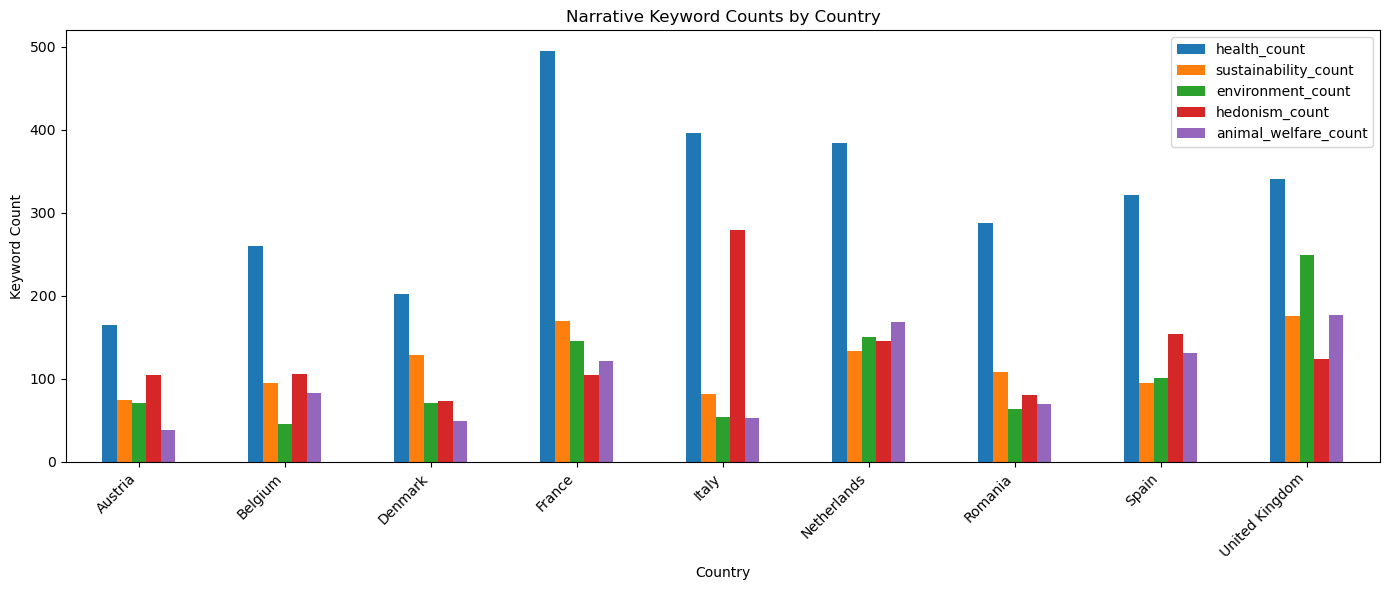

In [78]:

plot_df = country_narrative_summary.set_index("country")[narrative_count_cols]

plot_df.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Narrative Keyword Counts by Country")
plt.xlabel("Country")
plt.ylabel("Keyword Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This figure shows the frequency of different narrative keywords in YouTube videos across countries. Health-related keywords appear most frequently in almost all countries, suggesting that health is the dominant narrative in plant-based food videos. France, Italy, the Netherlands, Spain, and the United Kingdom show relatively high overall narrative counts. Sustainability and environmental narratives are also visible, especially in the United Kingdom and the Netherlands. Hedonism-related keywords are particularly high in Italy, while animal welfare is more prominent in the Netherlands, Spain, and the United Kingdom. Overall, the results suggest that health is the main narrative, but the emphasis on other narratives varies across countries.

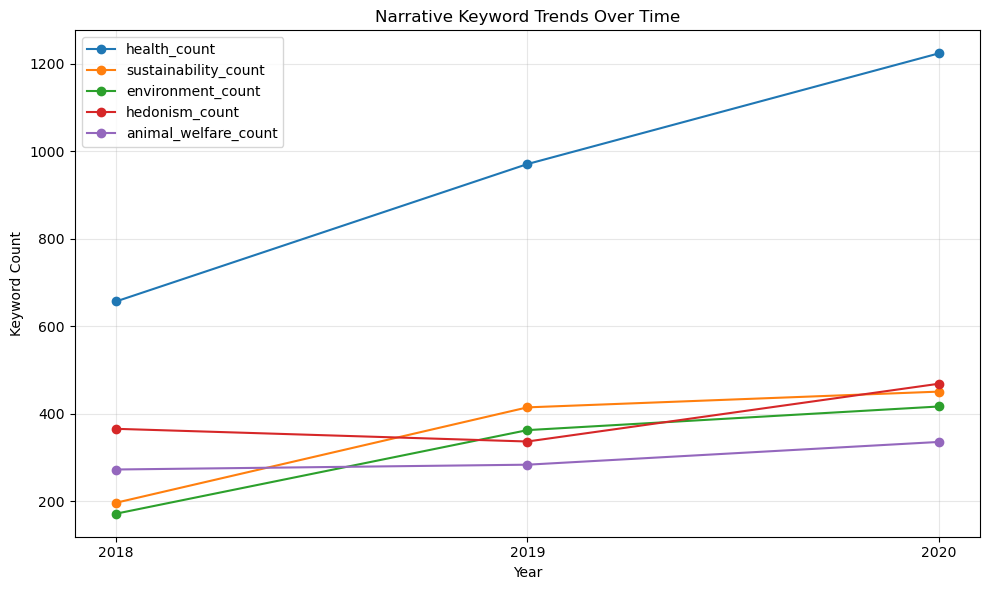

In [79]:
trend_df = country_year_narrative_summary.groupby("Year")[narrative_count_cols].sum()

trend_df.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Narrative Keyword Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Keyword Count")
plt.xticks([2018, 2019, 2020])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This figure shows how narrative keyword counts changed from 2018 to 2020. Health-related keywords increased strongly over time and remained the most dominant narrative in every year. Sustainability and environmental narratives also rose steadily, suggesting growing attention to ecological concerns. Hedonism-related keywords dipped slightly in 2019 but increased again in 2020, while animal welfare showed a more moderate upward trend. Overall, the results indicate that plant-based food narratives became more prominent over time, especially around health, sustainability, and environmental themes.

In [80]:
sales_year_country = df.groupby(['Country', 'Year'])[['Value EUR', 'Volume kg/l']].mean().reset_index()

sales_year_country.head()

,Country,Year,Value EUR,Volume kg/l
0,Austria,2018,1.533569e+06,4.685624e+05
1,Austria,2019,1.612946e+06,4.996007e+05
2,Austria,2020,2.244428e+06,6.603619e+05
3,Belgium,2018,6.231523e+06,2.174392e+06
4,Belgium,2019,6.583300e+06,2.233969e+06


In [81]:
narrative_path = Path("../data/Raw/youtube_narrative_summary_by_country_year.csv")

narrative_df = pd.read_csv(narrative_path)

narrative_df = narrative_df.rename(columns={
    "country": "Country"
})

narrative_df.head()

,Country,Year,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned
0,Austria,2018,62,46,29,16,22,6,0.322581,0.129032,0.177419,0.177419,0.048387
1,Austria,2019,93,47,23,11,35,10,0.225806,0.118280,0.075269,0.204301,0.064516
2,Austria,2020,110,72,23,44,48,23,0.209091,0.154545,0.136364,0.227273,0.090909
3,Belgium,2018,75,45,19,5,29,44,0.240000,0.093333,0.053333,0.226667,0.133333
4,Belgium,2019,100,107,34,15,30,16,0.280000,0.140000,0.050000,0.190000,0.080000


In [82]:
narrative_df["health_per_video"] = narrative_df["health_count"] / narrative_df["video_count"]

narrative_df["sustainability_environment_per_video"] = (
    narrative_df["sustainability_count"] + narrative_df["environment_count"]
) / narrative_df["video_count"]

narrative_df.head()

,Country,Year,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned,health_per_video,sustainability_environment_per_video
0,Austria,2018,62,46,29,16,22,6,0.322581,0.129032,0.177419,0.177419,0.048387,0.741935,0.725806
1,Austria,2019,93,47,23,11,35,10,0.225806,0.118280,0.075269,0.204301,0.064516,0.505376,0.365591
2,Austria,2020,110,72,23,44,48,23,0.209091,0.154545,0.136364,0.227273,0.090909,0.654545,0.609091
3,Belgium,2018,75,45,19,5,29,44,0.240000,0.093333,0.053333,0.226667,0.133333,0.600000,0.320000
4,Belgium,2019,100,107,34,15,30,16,0.280000,0.140000,0.050000,0.190000,0.080000,1.070000,0.490000


In [84]:
merged_df = pd.merge(
    sales_year_country,
    narrative_df,
    on=["Country", "Year"],
    how="inner"
)

print(merged_df.shape)
display(merged_df.head())

(27, 17)


,Country,Year,Value EUR,Volume kg/l,video_count,health_count,sustainability_count,environment_count,hedonism_count,animal_welfare_count,health_mentioned,sustainability_mentioned,environment_mentioned,hedonism_mentioned,animal_welfare_mentioned,health_per_video,sustainability_environment_per_video
0,Austria,2018,1.533569e+06,4.685624e+05,62,46,29,16,22,6,0.322581,0.129032,0.177419,0.177419,0.048387,0.741935,0.725806
1,Austria,2019,1.612946e+06,4.996007e+05,93,47,23,11,35,10,0.225806,0.118280,0.075269,0.204301,0.064516,0.505376,0.365591
2,Austria,2020,2.244428e+06,6.603619e+05,110,72,23,44,48,23,0.209091,0.154545,0.136364,0.227273,0.090909,0.654545,0.609091
3,Belgium,2018,6.231523e+06,2.174392e+06,75,45,19,5,29,44,0.240000,0.093333,0.053333,0.226667,0.133333,0.600000,0.320000
4,Belgium,2019,6.583300e+06,2.233969e+06,100,107,34,15,30,16,0.280000,0.140000,0.050000,0.190000,0.080000,1.070000,0.490000


In [85]:
corr1_df = merged_df[["health_per_video", "Value EUR"]].dropna()

X = sm.add_constant(corr1_df["health_per_video"])
y = corr1_df["Value EUR"]

model_health_value = sm.OLS(y, X).fit()

print(model_health_value.summary())

                            OLS Regression Results                            
Dep. Variable:              Value EUR   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.9569
Date:                Tue, 02 Jun 2026   Prob (F-statistic):              0.337
Time:                        22:15:58   Log-Likelihood:                -462.86
No. Observations:                  27   AIC:                             929.7
Df Residuals:                      25   BIC:                             932.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              3.83e+06   4.36e+06  

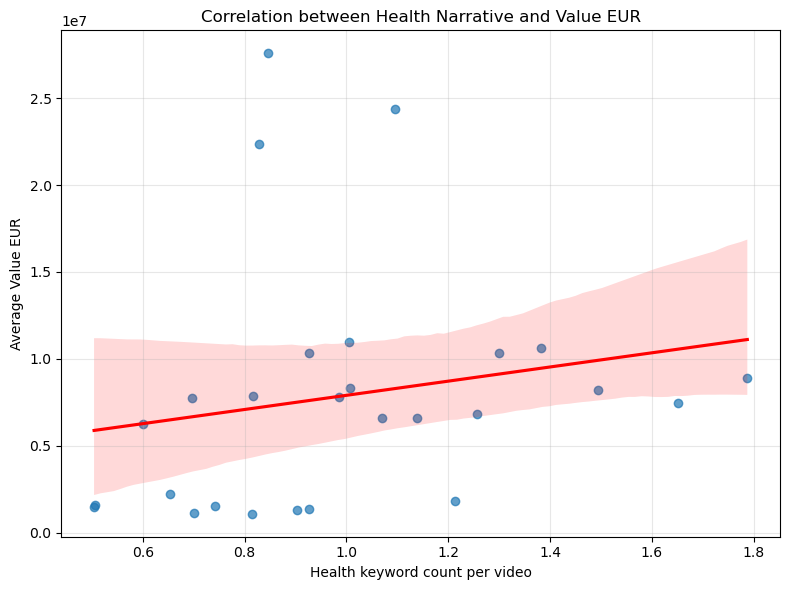

In [86]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=corr1_df,
    x="health_per_video",
    y="Value EUR",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.title("Correlation between Health Narrative and Value EUR")
plt.xlabel("Health keyword count per video")
plt.ylabel("Average Value EUR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The OLS regression examines whether health-related YouTube narrative intensity is associated with average sales value in EUR. The coefficient for health_per_video is positive, suggesting that country-year observations with more health-related keywords per video tend to have higher average sales value. However, the relationship is not statistically significant, as the p-value is 0.337, which is above the 0.05 threshold. The R-squared value is also low at 0.037, meaning that health narrative intensity explains only about 3.7% of the variation in Value EUR.

The scatter plot shows the same pattern: although the regression line slopes upward, the points are widely dispersed and the confidence interval is broad. Therefore, the result should be interpreted as weak and exploratory. In this dataset, health narratives appear to have a positive but non-significant relationship with sales value.

In [87]:
corr2_df = merged_df[["sustainability_environment_per_video", "Volume kg/l"]].dropna()

X = sm.add_constant(corr2_df["sustainability_environment_per_video"])
y = corr2_df["Volume kg/l"]

model_sustainability_volume = sm.OLS(y, X).fit()

print(model_sustainability_volume.summary())

                            OLS Regression Results                            
Dep. Variable:            Volume kg/l   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                 -0.026
Method:                 Least Squares   F-statistic:                    0.3408
Date:                Tue, 02 Jun 2026   Prob (F-statistic):              0.565
Time:                        22:16:21   Log-Likelihood:                -453.42
No. Observations:                  27   AIC:                             910.8
Df Residuals:                      25   BIC:                             913.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


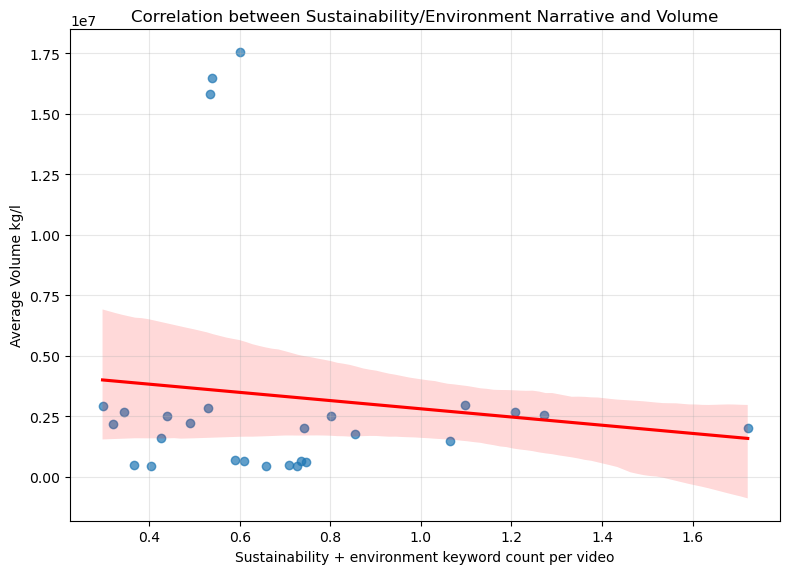

In [88]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=corr2_df,
    x="sustainability_environment_per_video",
    y="Volume kg/l",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.title("Correlation between Sustainability/Environment Narrative and Volume")
plt.xlabel("Sustainability + environment keyword count per video")
plt.ylabel("Average Volume kg/l")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The regression examines whether sustainability and environment narrative intensity is related to average sales volume. The coefficient is negative, suggesting a weak negative relationship between sustainability/environment keywords per video and volume. However, the p-value is 0.565, which is above 0.05, so this relationship is not statistically significant.

The R-squared value is only 0.013, meaning that this narrative variable explains very little variation in sales volume. Overall, the result suggests that sustainability and environmental narratives are not strongly associated with sales volume in this dataset.

In [93]:
sales_year_country = df.groupby(['Country', 'Year'])[['Value EUR', 'Volume kg/l']].mean().reset_index()

narrative_path = "../data/Raw/youtube_narrative_summary_by_country_year.csv"
narrative_df = pd.read_csv(narrative_path)

narrative_df = narrative_df.rename(columns={"country": "Country"})

merged_df = pd.merge(
    sales_year_country,
    narrative_df,
    on=["Country", "Year"],
    how="inner"
)

In [94]:
narrative_cols = [
    "health_count",
    "sustainability_count",
    "environment_count",
    "hedonism_count",
    "animal_welfare_count"
]

for col in narrative_cols:
    merged_df[col.replace("_count", "_per_video")] = (
        merged_df[col] / merged_df["video_count"]
    )

merged_df["total_narrative_per_video"] = (
    merged_df["health_per_video"] +
    merged_df["sustainability_per_video"] +
    merged_df["environment_per_video"] +
    merged_df["hedonism_per_video"] +
    merged_df["animal_welfare_per_video"]
)

In [95]:
corr_vars = [
    "Value EUR",
    "Volume kg/l",
    "video_count",
    "health_per_video",
    "sustainability_per_video",
    "environment_per_video",
    "hedonism_per_video",
    "animal_welfare_per_video",
    "total_narrative_per_video"
]

corr_matrix = merged_df[corr_vars].corr()

corr_matrix

,Value EUR,Volume kg/l,video_count,health_per_video,sustainability_per_video,environment_per_video,hedonism_per_video,animal_welfare_per_video,total_narrative_per_video
Value EUR,1.000000,0.942416,0.344299,0.191998,-0.191485,0.087887,0.254020,0.220164,0.220842
Volume kg/l,0.942416,1.000000,0.201841,0.026407,-0.220134,-0.018501,0.088011,0.146840,0.029638
video_count,0.344299,0.201841,1.000000,0.097581,0.099199,0.129828,-0.048564,-0.101884,0.062395
health_per_video,0.191998,0.026407,0.097581,1.000000,0.292380,0.351102,0.169593,0.269130,0.787970
sustainability_per_video,-0.191485,-0.220134,0.099199,0.292380,1.000000,0.599596,-0.518843,0.146036,0.444495
environment_per_video,0.087887,-0.018501,0.129828,0.351102,0.599596,1.000000,-0.165830,0.531233,0.732967
hedonism_per_video,0.254020,0.088011,-0.048564,0.169593,-0.518843,-0.165830,1.000000,0.152991,0.258203
animal_welfare_per_video,0.220164,0.146840,-0.101884,0.269130,0.146036,0.531233,0.152991,1.000000,0.689648
total_narrative_per_video,0.220842,0.029638,0.062395,0.787970,0.444495,0.732967,0.258203,0.689648,1.000000


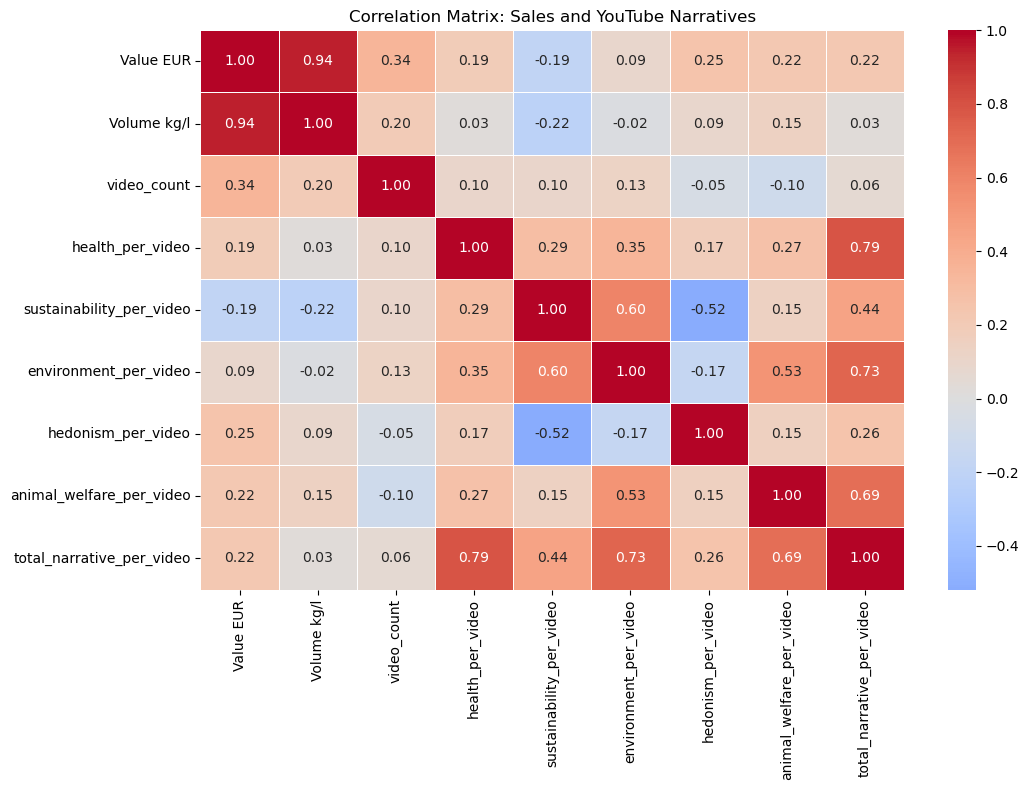

In [96]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix: Sales and YouTube Narratives")
plt.tight_layout()
plt.show()

This correlation matrix shows the relationships between sales indicators and YouTube narrative variables. The strongest relationship is between Value EUR and Volume kg/l with a correlation of 0.94, indicating that higher sales volume is strongly associated with higher market value. In contrast, the correlations between sales variables and narrative variables are generally weak. For example, Value EUR has only weak positive correlations with video_count, health_per_video, hedonism_per_video, and total_narrative_per_video.

The matrix also shows that some narrative categories are strongly related to each other. For example, health_per_video is highly correlated with total_narrative_per_video, and environment_per_video is also strongly related to total narrative intensity. Overall, the results suggest that sales value and volume are closely connected, while YouTube narratives have weaker and more exploratory associations with sales performance.

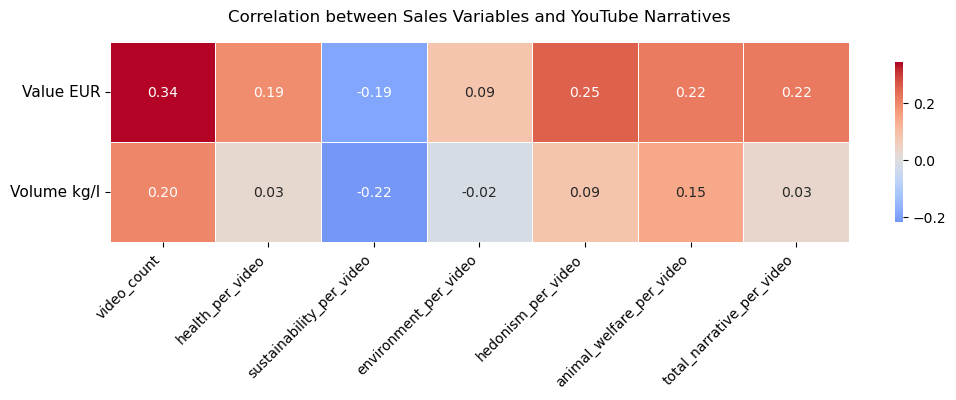

In [100]:
plt.figure(figsize=(12, 4))

ax = sns.heatmap(
    sales_narrative_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation between Sales Variables and YouTube Narratives", pad=15)

# Make y-axis labels readable
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=11
)

# Make x-axis labels readable
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=10
)

# Add more margin on the left and bottom
plt.subplots_adjust(left=0.18, bottom=0.35, right=0.95, top=0.85)

plt.show()

This heatmap shows that the correlations between sales variables and YouTube narratives are generally weak. Value EUR has the strongest positive correlation with video_count at 0.34, suggesting that higher YouTube attention is somewhat associated with higher sales value. Hedonism, animal welfare, and total narrative intensity also show weak positive correlations with Value EUR. In contrast, sustainability has a weak negative correlation with both Value EUR and Volume kg/l. Overall, YouTube narratives show only limited correlation with sales performance.

In [98]:
corr_long = sales_narrative_corr.stack().reset_index()
corr_long.columns = ["sales_variable", "narrative_variable", "correlation"]

corr_long["abs_correlation"] = corr_long["correlation"].abs()

top_corr = corr_long.sort_values(
    "abs_correlation",
    ascending=False
).head(2)

top_corr


,sales_variable,narrative_variable,correlation,abs_correlation
0,Value EUR,video_count,0.344299,0.344299
4,Value EUR,hedonism_per_video,0.254020,0.254020


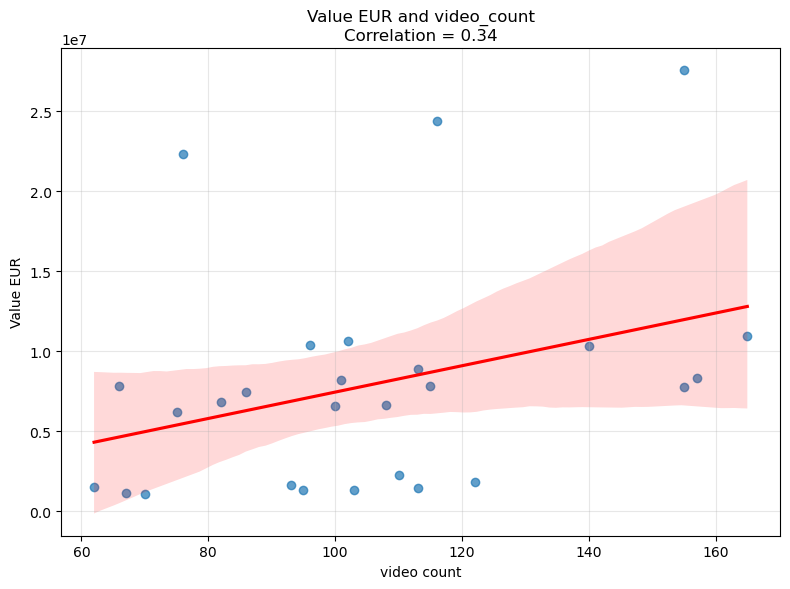

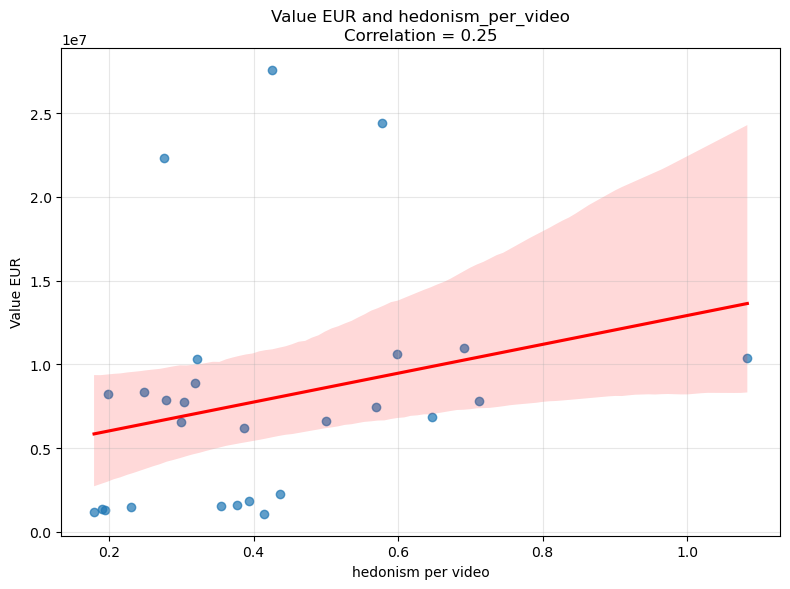

In [99]:
for _, row in top_corr.iterrows():
    sales_var = row["sales_variable"]
    narrative_var = row["narrative_variable"]
    corr_value = row["correlation"]

    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=merged_df,
        x=narrative_var,
        y=sales_var,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "red"}
    )

    plt.title(
        f"{sales_var} and {narrative_var}\nCorrelation = {corr_value:.2f}"
    )
    plt.xlabel(narrative_var.replace("_", " "))
    plt.ylabel(sales_var)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

These two scatter plots show weak positive relationships between YouTube activity/narratives and sales value. The first plot shows that video_count has a modest positive correlation with Value EUR (r = 0.34), suggesting that country-year groups with more YouTube videos tend to have higher sales value. The second plot shows a weaker positive correlation between hedonism_per_video and Value EUR (r = 0.25), indicating that taste or enjoyment-related narratives may be slightly associated with higher sales value. However, both relationships are relatively weak, so they should be interpreted as exploratory rather than strong evidence.